In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List, Optional

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
# 1) Vanilla RNN Cell

A Vanilla RNN processes sequences one timestep at a time, maintaining a **hidden state** $h_t$ that serves as the network's "memory." At each step, the hidden state is updated as a function of the previous hidden state and the current input:

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$
$$y_t = W_{hy} \cdot h_t + b_y$$

**Key limitation**: During backpropagation through time (BPTT), gradients are multiplied by $W_{hh}$ at each timestep. If the largest singular value of $W_{hh}$ is < 1, gradients shrink exponentially (**vanishing**); if > 1, they explode (**exploding**). This makes learning long-range dependencies very difficult.

In [2]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """Numerically stable sigmoid."""
    return np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))

def softmax(x: np.ndarray) -> np.ndarray:
    """Column-wise softmax (each column is a sample in a batch)."""
    e_x = np.exp(x - np.max(x, axis=0, keepdims=True))
    return e_x / e_x.sum(axis=0, keepdims=True)

In [3]:
def rnn_cell_forward(
    x_t: np.ndarray,
    h_prev: np.ndarray,
    params: Dict[str, np.ndarray],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Vanilla RNN cell — single timestep forward pass.

    Convention: we use column-vectors per sample, so shapes are (dim, batch_num).
    This matches the math notation where W @ x multiplies from the left.
    """
    W_xh = params["W_xh"]  # (hidden_dim, input_dim)
    W_hh = params["W_hh"]  # (hidden_dim, hidden_dim)
    b_h = params["b_h"]    # (hidden_dim, 1)
    W_hy = params["W_hy"]  # (output_dim, hidden_dim)
    b_y = params["b_y"]    # (output_dim, 1)

    # Compute next hidden state
    # (hidden_dim, batch_num)
    h_next = np.tanh(W_hh @ h_prev + W_xh @ x_t + b_h)

    # Compute output prediction
    # (output_dim, batch_num)
    y_t = softmax(W_hy @ h_next + b_y)

    return h_next, y_t


def rnn_forward(
    x: np.ndarray,
    h_0: np.ndarray,
    params: Dict[str, np.ndarray],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Full RNN forward pass over T timesteps.

    Args:
        x: (input_dim, batch_num, seq_len)
        h_0: (hidden_dim, batch_num)
    Returns:
        h_all: (hidden_dim, batch_num, seq_len)
        y_all: (output_dim, batch_num, seq_len)
    """
    input_dim, batch_num, seq_len = x.shape
    output_dim = params["W_hy"].shape[0]
    hidden_dim = params["W_hh"].shape[0]

    h_all = np.zeros((hidden_dim, batch_num, seq_len))
    y_all = np.zeros((output_dim, batch_num, seq_len))
    h_t = h_0

    for t in range(seq_len):
        # (input_dim, batch_num) at timestep t
        h_t, y_t = rnn_cell_forward(x[:, :, t], h_t, params)
        h_all[:, :, t] = h_t
        y_all[:, :, t] = y_t

    return h_all, y_all

In [4]:
# Quick sanity check with random data
input_dim, hidden_dim, output_dim, batch_num, seq_len = 3, 5, 2, 10, 4

rnn_params = {
    "W_xh": np.random.randn(hidden_dim, input_dim) * 0.01,
    "W_hh": np.random.randn(hidden_dim, hidden_dim) * 0.01,
    "b_h": np.zeros((hidden_dim, 1)),
    "W_hy": np.random.randn(output_dim, hidden_dim) * 0.01,
    "b_y": np.zeros((output_dim, 1)),
}

x_test = np.random.randn(input_dim, batch_num, seq_len)
h_0_test = np.zeros((hidden_dim, batch_num))

h_all, y_all = rnn_forward(x_test, h_0_test, rnn_params)
print(f"h_all.shape = {h_all.shape}  # (hidden_dim, batch_num, seq_len)")
print(f"y_all.shape = {y_all.shape}  # (output_dim, batch_num, seq_len)")
print(f"y_all sums per sample (should be ~1.0): {y_all[:, 0, 0].sum():.4f}")

h_all.shape = (5, 10, 4)  # (hidden_dim, batch_num, seq_len)
y_all.shape = (2, 10, 4)  # (output_dim, batch_num, seq_len)
y_all sums per sample (should be ~1.0): 1.0000


**Vanishing Gradient Problem**

We show that when we repeatedly multiply by `W_hh`, the gradient norm either vanishes or explodes depending on the spectral radius of `W_hh`. This is the fundamental reason Vanilla RNNs fail on long sequences.

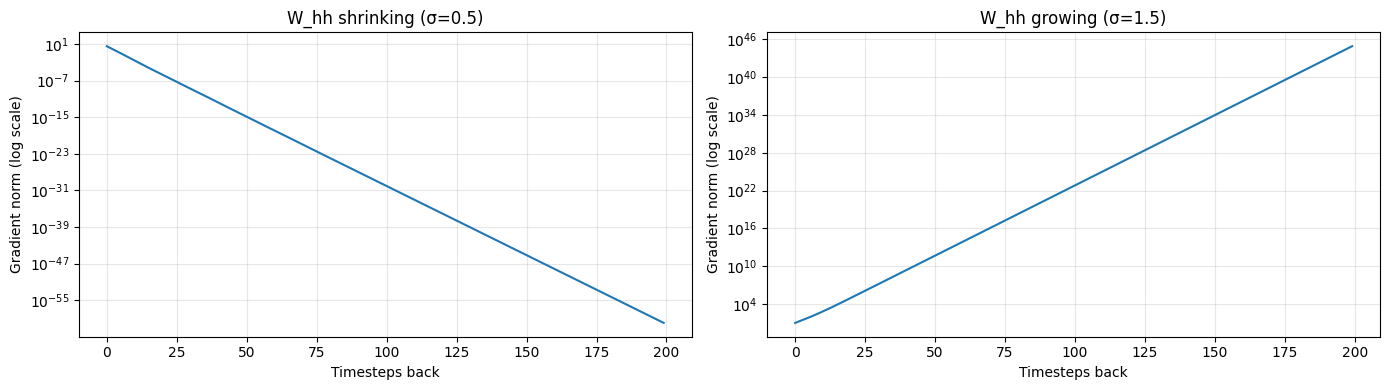

Left: gradients vanish → network forgets distant past.
Right: gradients explode → training becomes unstable.
GRU and LSTM solve this via gating mechanisms.


In [5]:
def demonstrate_vanishing_gradient(hidden_dim: int = 50, seq_lengths: list = [10, 50, 100, 200]):
    """
    Simulate repeated multiplication by W_hh to show gradient
    magnitude decay/growth over time.
    """
    results = {}

    for scale_label, w_scale in [("shrinking (σ=0.5)", 0.5), ("growing (σ=1.5)", 1.5)]:
        W = np.random.randn(hidden_dim, hidden_dim) * (w_scale / np.sqrt(hidden_dim))
        norms = []
        grad = np.eye(hidden_dim)

        for t in range(max(seq_lengths)):
            # Jacobian of tanh at 0 is identity, so near initialization
            # the gradient flow is dominated by W_hh multiplication
            grad = W @ grad
            norms.append(np.linalg.norm(grad))

        results[scale_label] = norms

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, (label, norms) in zip(axes, results.items()):
        ax.semilogy(norms)
        ax.set_xlabel("Timesteps back")
        ax.set_ylabel("Gradient norm (log scale)")
        ax.set_title(f"W_hh {label}")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


demonstrate_vanishing_gradient()
print("Left: gradients vanish → network forgets distant past.")
print("Right: gradients explode → training becomes unstable.")
print("GRU and LSTM solve this via gating mechanisms.")

---
# 2) GRU Cell

The GRU (Gated Recurrent Unit) introduces two gates to control information flow:

- **Reset gate** $r_t$: controls how much of the previous hidden state to "forget" when computing the candidate.
- **Update gate** $z_t$: controls how much of the candidate vs. the old hidden state to keep.

$$r_t = \sigma(W_r [h_{t-1}, x_t] + b_r)$$
$$z_t = \sigma(W_z [h_{t-1}, x_t] + b_z)$$
$$\tilde{h}_t = \tanh(W_h [r_t \odot h_{t-1}, x_t] + b_h)$$
$$h_t = z_t \odot \tilde{h}_t + (1 - z_t) \odot h_{t-1}$$

**Why this fixes vanishing gradients**: When $z_t \approx 0$, we get $h_t \approx h_{t-1}$ — the gradient flows through an identity-like path, avoiding the repeated multiplication by $W_{hh}$ that causes vanishing.

**Sample I/O** (same shapes as Vanilla RNN — GRU has no separate cell state):

| Tensor | Shape |
|--------|-------|
| `x_t` | `(input_dim, batch_num)` |
| `h_prev` | `(hidden_dim, batch_num)` |
| `h_next` | `(hidden_dim, batch_num)` |

In [6]:
def gru_cell_forward(
    x_t: np.ndarray,
    h_prev: np.ndarray,
    params: Dict[str, np.ndarray],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    GRU cell — single timestep forward pass.

    Weight matrices W_r, W_z, W_h have shape (hidden_dim, hidden_dim + input_dim)
    because we concatenate [h_prev, x_t] before multiplying.
    """
    W_r, b_r = params["W_r"], params["b_r"]
    W_z, b_z = params["W_z"], params["b_z"]
    W_h, b_h = params["W_h"], params["b_h"]
    W_hy, b_y = params["W_hy"], params["b_y"]

    # Concatenate h_prev and x_t along the feature axis
    # (hidden_dim + input_dim, batch_num)
    concat = np.concatenate([h_prev, x_t], axis=0)

    # Reset gate: decides how much of h_prev to expose to candidate computation
    # (hidden_dim, batch_num)
    r_t = sigmoid(W_r @ concat + b_r)

    # Update gate: decides blend ratio between old h and candidate
    # (hidden_dim, batch_num)
    z_t = sigmoid(W_z @ concat + b_z)

    # Candidate hidden state: uses reset gate to selectively read h_prev
    # (hidden_dim + input_dim, batch_num)
    concat_reset = np.concatenate([r_t * h_prev, x_t], axis=0)
    # (hidden_dim, batch_num)
    h_tilde = np.tanh(W_h @ concat_reset + b_h)

    # Final hidden state: interpolation between old and candidate
    # When z_t ≈ 0, h_next ≈ h_prev (gradient highway — no vanishing)
    # (hidden_dim, batch_num)
    h_next = z_t * h_tilde + (1 - z_t) * h_prev

    # Output prediction
    # (output_dim, batch_num)
    y_t = softmax(W_hy @ h_next + b_y)

    return h_next, y_t

In [7]:
def gru_forward(
    x: np.ndarray,
    h_0: np.ndarray,
    params: Dict[str, np.ndarray],
) -> Tuple[np.ndarray, np.ndarray]:
    """Full GRU forward pass over seq_len timesteps."""
    input_dim, batch_num, seq_len = x.shape
    hidden_dim = params["W_r"].shape[0]
    output_dim = params["W_hy"].shape[0]

    h_all = np.zeros((hidden_dim, batch_num, seq_len))
    y_all = np.zeros((output_dim, batch_num, seq_len))
    h_t = h_0

    for t in range(seq_len):
        h_t, y_t = gru_cell_forward(x[:, :, t], h_t, params)
        h_all[:, :, t] = h_t
        y_all[:, :, t] = y_t

    return h_all, y_all


# Sanity check
input_dim, hidden_dim, output_dim, batch_num, seq_len = 3, 5, 2, 10, 7
concat_dim = hidden_dim + input_dim

gru_params = {
    "W_r": np.random.randn(hidden_dim, concat_dim) * 0.01,
    "b_r": np.zeros((hidden_dim, 1)),
    "W_z": np.random.randn(hidden_dim, concat_dim) * 0.01,
    "b_z": np.zeros((hidden_dim, 1)),
    "W_h": np.random.randn(hidden_dim, concat_dim) * 0.01,
    "b_h": np.zeros((hidden_dim, 1)),
    "W_hy": np.random.randn(output_dim, hidden_dim) * 0.01,
    "b_y": np.zeros((output_dim, 1)),
}

x_test = np.random.randn(input_dim, batch_num, seq_len)
h_0_test = np.zeros((hidden_dim, batch_num))
h_all, y_all = gru_forward(x_test, h_0_test, gru_params)
print(f"h_all.shape = {h_all.shape}  # (hidden_dim, batch_num, seq_len)")
print(f"y_all.shape = {y_all.shape}  # (output_dim, batch_num, seq_len)")

h_all.shape = (5, 10, 7)  # (hidden_dim, batch_num, seq_len)
y_all.shape = (2, 10, 7)  # (output_dim, batch_num, seq_len)


---
# 3) LSTM Cell


The LSTM separates the hidden state into two components:
- **Cell state** $c_t$: the long-term memory highway (analogous to a conveyor belt)
- **Hidden state** $h_t$: the short-term / working memory

Three gates control information flow:

| Gate | Formula | Role |
|------|---------|------|
| Forget | $f_t = \sigma(W_f[h_{t-1}, x_t] + b_f)$ | What to erase from cell state |
| Input | $i_t = \sigma(W_i[h_{t-1}, x_t] + b_i)$ | What new info to write |
| Output | $o_t = \sigma(W_o[h_{t-1}, x_t] + b_o)$ | What to expose as hidden state |

Cell and hidden state updates:
$$\tilde{c}_t = \tanh(W_c[h_{t-1}, x_t] + b_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

**Why the cell state fixes vanishing gradients**: The cell state update $c_t = f_t \odot c_{t-1} + ...$ is an **additive** interaction. When $f_t \approx 1$, the gradient flows through $c_{t-1}$ virtually unchanged — no repeated matrix multiplication.

**Key difference vs GRU**: LSTM has 3 gates + separate cell state (more parameters, more expressive). GRU has 2 gates and merges cell/hidden state (fewer parameters, sometimes faster to train).

**Sample I/O:**

| Tensor | Shape |
|--------|-------|
| `x_t` | `(input_dim, batch_num)` |
| `h_prev` | `(hidden_dim, batch_num)` |
| `c_prev` | `(hidden_dim, batch_num)` |
| `h_next` | `(hidden_dim, batch_num)` |
| `c_next` | `(hidden_dim, batch_num)` |

In [8]:
def lstm_cell_forward(
    x_t: np.ndarray,
    h_prev: np.ndarray,
    c_prev: np.ndarray,
    params: Dict[str, np.ndarray],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    LSTM cell — single timestep forward pass.

    All gate weight matrices have shape (hidden_dim, hidden_dim + input_dim)
    because we concatenate [h_prev, x_t].
    """
    W_f, b_f = params["W_f"], params["b_f"]
    W_i, b_i = params["W_i"], params["b_i"]
    W_c, b_c = params["W_c"], params["b_c"]
    W_o, b_o = params["W_o"], params["b_o"]
    W_hy, b_y = params["W_hy"], params["b_y"]

    # Concatenate h_prev and x_t
    # (hidden_dim + input_dim, batch_num)
    concat = np.concatenate([h_prev, x_t], axis=0)

    # Forget gate: what fraction of each cell state dimension to retain
    # (hidden_dim, batch_num)
    f_t = sigmoid(W_f @ concat + b_f)

    # Input gate: what fraction of the candidate to write
    # (hidden_dim, batch_num)
    i_t = sigmoid(W_i @ concat + b_i)

    # Candidate cell state
    # (hidden_dim, batch_num)
    c_tilde = np.tanh(W_c @ concat + b_c)

    # New cell state: additive update preserves gradient flow
    # (hidden_dim, batch_num)
    c_next = f_t * c_prev + i_t * c_tilde

    # Output gate: what to expose from the cell state
    # (hidden_dim, batch_num)
    o_t = sigmoid(W_o @ concat + b_o)

    # Hidden state: filtered view of cell state
    # (hidden_dim, batch_num)
    h_next = o_t * np.tanh(c_next)

    # Output prediction
    # (output_dim, batch_num)
    y_t = softmax(W_hy @ h_next + b_y)

    return h_next, c_next, y_t

In [9]:
def lstm_forward(
    x: np.ndarray,
    h_0: np.ndarray,
    c_0: np.ndarray,
    params: Dict[str, np.ndarray],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Full LSTM forward pass over seq_len timesteps."""
    input_dim, batch_num, seq_len = x.shape
    hidden_dim = params["W_f"].shape[0]
    output_dim = params["W_hy"].shape[0]

    h_all = np.zeros((hidden_dim, batch_num, seq_len))
    c_all = np.zeros((hidden_dim, batch_num, seq_len))
    y_all = np.zeros((output_dim, batch_num, seq_len))
    h_t, c_t = h_0, c_0

    for t in range(seq_len):
        h_t, c_t, y_t = lstm_cell_forward(x[:, :, t], h_t, c_t, params)
        h_all[:, :, t] = h_t
        c_all[:, :, t] = c_t
        y_all[:, :, t] = y_t

    return h_all, c_all, y_all


# Sanity check
input_dim, hidden_dim, output_dim, batch_num, seq_len = 3, 5, 2, 10, 7
concat_dim = hidden_dim + input_dim

lstm_params = {
    "W_f": np.random.randn(hidden_dim, concat_dim) * 0.01,
    "b_f": np.zeros((hidden_dim, 1)),
    "W_i": np.random.randn(hidden_dim, concat_dim) * 0.01,
    "b_i": np.zeros((hidden_dim, 1)),
    "W_c": np.random.randn(hidden_dim, concat_dim) * 0.01,
    "b_c": np.zeros((hidden_dim, 1)),
    "W_o": np.random.randn(hidden_dim, concat_dim) * 0.01,
    "b_o": np.zeros((hidden_dim, 1)),
    "W_hy": np.random.randn(output_dim, hidden_dim) * 0.01,
    "b_y": np.zeros((output_dim, 1)),
}

x_test = np.random.randn(input_dim, batch_num, seq_len)
h_0_test = np.zeros((hidden_dim, batch_num))
c_0_test = np.zeros((hidden_dim, batch_num))

h_all, c_all, y_all = lstm_forward(x_test, h_0_test, c_0_test, lstm_params)
print(f"h_all.shape = {h_all.shape}  # (hidden_dim, batch_num, seq_len)")
print(f"c_all.shape = {c_all.shape}  # (hidden_dim, batch_num, seq_len)")
print(f"y_all.shape = {y_all.shape}  # (output_dim, batch_num, seq_len)")

h_all.shape = (5, 10, 7)  # (hidden_dim, batch_num, seq_len)
c_all.shape = (5, 10, 7)  # (hidden_dim, batch_num, seq_len)
y_all.shape = (2, 10, 7)  # (output_dim, batch_num, seq_len)


---
# 4) PyTorch Equivalents — Side-by-Side Comparison

In practice, you use `nn.RNNCell`, `nn.GRUCell`, `nn.LSTMCell` (or the full `nn.RNN`, `nn.GRU`, `nn.LSTM` modules that loop internally). Here we verify that our from-scratch implementations match PyTorch's behavior by comparing output shapes and confirming identical computation when weights are shared.

**Key PyTorch conventions** (different from our NumPy code):
- PyTorch uses **row vectors**: `(batch_num, feature_dim)` instead of `(feature_dim, batch_num)`
- `nn.LSTM` returns `(output, (h_n, c_n))` where output has shape `(batch_num, seq_len, hidden_dim)` with `batch_first=True`

In [10]:
batch_num, seq_len, input_dim, hidden_dim = 4, 16, 64, 128

# Shared input: (batch_num, seq_len, input_dim)
x = torch.randn(batch_num, seq_len, input_dim)

print("=" * 60)
print("Vanilla RNN")
print("=" * 60)
rnn_cell = nn.RNNCell(input_dim, hidden_dim)
h = torch.zeros(batch_num, hidden_dim)
outputs_rnn = []
for t in range(seq_len):
    # (batch_num, input_dim) → (batch_num, hidden_dim)
    h = rnn_cell(x[:, t, :], h)
    outputs_rnn.append(h)
# Stack: (batch_num, seq_len, hidden_dim)
rnn_out = torch.stack(outputs_rnn, dim=1)
print(f"  Manual loop output: {rnn_out.shape}")

# Equivalent using nn.RNN (loops internally)
rnn_module = nn.RNN(input_dim, hidden_dim, batch_first=True)
# (batch_num, seq_len, hidden_dim), (1, batch_num, hidden_dim)
rnn_out_2, h_n = rnn_module(x)
print(f"  nn.RNN output:      {rnn_out_2.shape}, h_n: {h_n.shape}")

print("\n" + "=" * 60)
print("GRU")
print("=" * 60)
gru_cell = nn.GRUCell(input_dim, hidden_dim)
h = torch.zeros(batch_num, hidden_dim)
outputs_gru = []
for t in range(seq_len):
    # (batch_num, input_dim) → (batch_num, hidden_dim)
    h = gru_cell(x[:, t, :], h)
    outputs_gru.append(h)
gru_out = torch.stack(outputs_gru, dim=1)
print(f"  Manual loop output: {gru_out.shape}")

gru_module = nn.GRU(input_dim, hidden_dim, batch_first=True)
gru_out_2, h_n = gru_module(x)
print(f"  nn.GRU output:      {gru_out_2.shape}, h_n: {h_n.shape}")

print("\n" + "=" * 60)
print("LSTM")
print("=" * 60)
lstm_cell = nn.LSTMCell(input_dim, hidden_dim)
h = torch.zeros(batch_num, hidden_dim)
c = torch.zeros(batch_num, hidden_dim)
outputs_lstm = []
for t in range(seq_len):
    # (batch_num, input_dim) → (batch_num, hidden_dim), (batch_num, hidden_dim)
    h, c = lstm_cell(x[:, t, :], (h, c))
    outputs_lstm.append(h)
lstm_out = torch.stack(outputs_lstm, dim=1)
print(f"  Manual loop output: {lstm_out.shape}")

lstm_module = nn.LSTM(input_dim, hidden_dim, batch_first=True)
# (batch_num, seq_len, hidden_dim), ((1, batch_num, hidden_dim), (1, batch_num, hidden_dim))
lstm_out_2, (h_n, c_n) = lstm_module(x)
print(f"  nn.LSTM output:     {lstm_out_2.shape}, h_n: {h_n.shape}, c_n: {c_n.shape}")

Vanilla RNN
  Manual loop output: torch.Size([4, 16, 128])
  nn.RNN output:      torch.Size([4, 16, 128]), h_n: torch.Size([1, 4, 128])

GRU
  Manual loop output: torch.Size([4, 16, 128])
  nn.GRU output:      torch.Size([4, 16, 128]), h_n: torch.Size([1, 4, 128])

LSTM
  Manual loop output: torch.Size([4, 16, 128])
  nn.LSTM output:     torch.Size([4, 16, 128]), h_n: torch.Size([1, 4, 128]), c_n: torch.Size([1, 4, 128])


In [11]:
input_dim, hidden_dim = 64, 128

models = {
    "Vanilla RNN": nn.RNN(input_dim, hidden_dim, batch_first=True),
    "GRU": nn.GRU(input_dim, hidden_dim, batch_first=True),
    "LSTM": nn.LSTM(input_dim, hidden_dim, batch_first=True),
}

print(f"{'Model':<15} {'Parameters':>12}  Notes")
print("-" * 60)
for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters())
    # RNN: 1 gate, GRU: 3 gates, LSTM: 4 gates
    # Each gate has: W_ih (hidden_dim, input_dim) + W_hh (hidden_dim, hidden_dim) + 2 biases
    print(f"{name:<15} {n_params:>12,}  ")

print("\nRatio: LSTM has ~4x params of Vanilla RNN, GRU has ~3x.")
print("GRU is often preferred when data is limited (fewer params to overfit).")

Model             Parameters  Notes
------------------------------------------------------------
Vanilla RNN           24,832  
GRU                   74,496  
LSTM                  99,328  

Ratio: LSTM has ~4x params of Vanilla RNN, GRU has ~3x.
GRU is often preferred when data is limited (fewer params to overfit).


---
# 5) Character-Level Language Model — Dinosaur Name Generator

We tie everything together by building a **character-level language model** that learns to generate dinosaur names. This demonstrates:

1. **LSTM in practice**: processing variable-length sequences
2. **Gradient clipping**: essential for stable RNN training
3. **Sampling from a trained model**: generating novel sequences

The model predicts the next character given all previous characters:
$$P(x_{t+1} | x_1, x_2, ..., x_t)$$

**Training**: Teacher forcing — feed the ground-truth character at each step.
**Inference**: Feed the model's own prediction back as the next input (autoregressive sampling).

## 5.1 Data Preparation

In [12]:
# Inline dinosaur name dataset (no external download needed)
DINO_NAMES = """Aachenosaurus
Aardonyx
Abdallahsaurus
Abelisaurus
Abrictosaurus
Abrosaurus
Abydosaurus
Acanthopholis
Achelousaurus
Achillobator
Acrocanthosaurus
Adamantisaurus
Adasaurus
Adeopapposaurus
Aegyptosaurus
Afrovenator
Agilisaurus
Agnosphitys
Alamosaurus
Albertaceratops
Albertosaurus
Alectrosaurus
Alioramus
Allosaurus
Alvarezsaurus
Amargasaurus
Ammosaurus
Ampelosaurus
Amphicoelias
Anchiceratops
Anchisaurus
Andesaurus
Angaturama
Ankylosaurus
Anserimimus
Antarctopelta
Antarctosaurus
Apatosaurus
Aragosaurus
Aralosaurus
Archaeoceratops
Archaeopteryx
Archaeornithomimus
Argentinosaurus
Arrhinoceratops
Atlascopcosaurus
Aucasaurus
Austrosaurus
Bactrosaurus
Bagaceratops
Bambiraptor
Barapasaurus
Barosaurus
Baryonyx
Becklespinax
Beipiaosaurus
Borogovia
Brachiosaurus
Brachylophosaurus
Buitreraptor
Camarasaurus
Camptosaurus
Carnotaurus
Caudipteryx
Cedarpelta
Centrosaurus
Ceratosaurus
Cetiosaurus
Chindesaurus
Chubutisaurus
Citipati
Coelophysis
Coelurus
Compsognathus
Conchoraptor
Corythosaurus
Cryolophosaurus
Dacentrurus
Daspletosaurus
Datousaurus
Deinocheirus
Deinonychus
Deltadromeus
Dicraeosaurus
Dilophosaurus
Diplodocus
Dracorex
Dromaeosaurus
Dromiceiomimus
Dryosaurus
Edmontonia
Edmontosaurus
Einiosaurus
Elaphrosaurus
Emausaurus
Eoraptor
Eotyrannus
Erketu
Erlikosaurus
Euhelopus
Euoplocephalus
Europasaurus
Eustreptospondylus
Fukuiraptor
Fukuisaurus
Gallimimus
Gargoyleosaurus
Garudimimus
Gasosaurus
Gasparinisaura
Giganotosaurus
Gilmoreosaurus
Giraffatitan
Gobisaurus
Gorgosaurus
Goyocephale
Graciliceratops
Guaibasaurus
Guanlong
Hadrosaurus
Hagryphus
Haplocanthosaurus
Harpymimus
Herrerasaurus
Hesperosaurus
Heterodontosaurus
Huayangosaurus
Hylaeosaurus
Hypacrosaurus
Hypsilophodon
Iguanodon
Irritator
Jaxartosaurus
Jingshanosaurus
Jobaria
Kentrosaurus
Khaan
Kotasaurus
Kritosaurus
Lambeosaurus
Leaellynasaura
Leptoceratops
Lesothosaurus
Lexovisaurus
Lirainosaurus
Lophostropheus
Lufengosaurus
Lurdusaurus
Lycorhinus
Magyarosaurus
Maiasaura
Majungasaurus
Malawisaurus
Mamenchisaurus
Mapusaurus
Marshosaurus
Masiakasaurus
Massospondylus
Maxakalisaurus
Megalosaurus
Melanorosaurus
Metriacanthosaurus
Microceratops
Micropachycephalosaurus
Microraptor
Minmi
Monolophosaurus
Mononykus
Mussaurus
Muttaburrasaurus
Nanotyrannus
Nedoceratops
Neuquensaurus
Nigersaurus
Nipponosaurus
Noasaurus
Nomingia
Nothronychus
Nqwebasaurus
Olorotitan
Opisthocoelicaudia
Ornithomimus
Orodromeus
Oryctodromeus
Othnielia
Ouranosaurus
Oviraptor
Pachycephalosaurus
Pachyrhinosaurus
Pantydraco
Paralititan
Parasaurolophus
Parvicursor
Patagosaurus
Pelicanimimus
Pentaceratops
Pinacosaurus
Plateosaurus
Polacanthus
Prenocephale
Probactrosaurus
Protoceratops
Psittacosaurus
Quaesitosaurus
Rajasaurus
Rapetosaurus
Rebbachisaurus
Rhabdodon
Rhoetosaurus
Rinchenia
Riojasaurus
Saichania
Saltasaurus
Saltopus
Saurolophus
Sauropelta
Saurornithoides
Scelidosaurus
Scutellosaurus
Segisaurus
Segnosaurus
Shanag
Shantungosaurus
Shunosaurus
Silvisaurus
Sinocalliopteryx
Sinornithosaurus
Sinosauropteryx
Spinosaurus
Staurikosaurus
Stegoceras
Stegosaurus
Struthiomimus
Styracosaurus
Suchomimus
Supersaurus
Talarurus
Tarbosaurus
Tarchia
Tenontosaurus
Therizinosaurus
Torosaurus
Triceratops
Troodon
Tsintaosaurus
Tuojiangosaurus
Tyrannosaurus
Unenlagia
Urbacodon
Utahraptor
Velociraptor
Vulcanodon
Wannanosaurus
Wuerhosaurus
Xenotarsosaurus
Xiaosaurus
Yangchuanosaurus
Yingshanosaurus
Yunnanosaurus
Zalmoxes
Zephyrosaurus
Zuniceratops"""

# Build character vocabulary
data = DINO_NAMES.lower()
chars = sorted(list(set(data)))
vocab_size = len(chars)

char_to_ix = {ch: i for i, ch in enumerate(chars)}
ix_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"Vocabulary ({vocab_size} chars): {chars}")
print(f"'\\n' is at index {char_to_ix[chr(10)]}, used as EOS token")

# Parse names into a list
names = [name.strip().lower() for name in DINO_NAMES.strip().split("\n")]
print(f"\nNumber of names: {len(names)}")
print(f"Examples: {names[:5]}")

Vocabulary (27 chars): ['\n', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
'\n' is at index 0, used as EOS token

Number of names: 262
Examples: ['aachenosaurus', 'aardonyx', 'abdallahsaurus', 'abelisaurus', 'abrictosaurus']


## 5.2 Architecture

Architecture:
```
char index → Embedding(vocab_size, embed_dim) → LSTM(embed_dim, hidden_dim) → Linear(hidden_dim, vocab_size) → softmax
```

Key design decisions:
- **Embedding layer** instead of one-hot: more parameter-efficient, learnable representations
- **Single LSTM layer**: dataset is tiny (~230 names), deeper models would overfit
- **Gradient clipping**: `clip_grad_norm_` to prevent exploding gradients

In [13]:
class CharLSTM(nn.Module):
    """Character-level LSTM language model."""

    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Character embedding: maps integer indices to dense vectors
        # (vocab_size) → (vocab_size, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # LSTM: processes the embedded sequence
        # (batch_num, seq_len, embed_dim) → (batch_num, seq_len, hidden_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        # Output projection: maps hidden state to vocabulary logits
        # (batch_num, seq_len, hidden_dim) → (batch_num, seq_len, vocab_size)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(
        self,
        x: torch.Tensor,
        hidden: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
    ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        Args:
            x: (batch_num, seq_len) integer character indices
            hidden: optional (h_0, c_0) each of shape (1, batch_num, hidden_dim)
        Returns:
            logits: (batch_num, seq_len, vocab_size)
            hidden: (h_n, c_n)
        """
        # (batch_num, seq_len) → (batch_num, seq_len, embed_dim)
        embedded = self.embedding(x)

        # (batch_num, seq_len, embed_dim) → (batch_num, seq_len, hidden_dim)
        lstm_out, hidden = self.lstm(embedded, hidden)

        # (batch_num, seq_len, hidden_dim) → (batch_num, seq_len, vocab_size)
        logits = self.fc(lstm_out)

        return logits, hidden

    def init_hidden(self, batch_num: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Zero-initialize hidden and cell states."""
        # (num_layers, batch_num, hidden_dim)
        h_0 = torch.zeros(1, batch_num, self.hidden_dim, device=device)
        c_0 = torch.zeros(1, batch_num, self.hidden_dim, device=device)
        return (h_0, c_0)

## 5.3 Gradient Clipping

Gradient clipping bounds the global norm of all gradients to a maximum value. This prevents the "exploding gradient" problem without affecting the gradient direction (only scales it down when too large).

$$\text{if } \|g\| > \text{max_norm}: \quad g \leftarrow g \cdot \frac{\text{max_norm}}{\|g\|}$$

PyTorch provides `torch.nn.utils.clip_grad_norm_` which we use below. A typical value is `max_norm=5.0`.

## 5.4 Sampling Function

After training, we generate names by:
1. Starting with a newline character (or a specific seed)
2. Feeding the character through the model to get a probability distribution over the next character
3. Sampling from that distribution (with optional temperature scaling)
4. Repeating until we generate a newline (EOS) or hit a max length

In [14]:
@torch.no_grad()
def sample_name(
    model: CharLSTM,
    char_to_ix: dict,
    ix_to_char: dict,
    max_len: int = 50,
    temperature: float = 0.8,
    seed_char: Optional[str] = None,
) -> str:
    """
    Autoregressively sample a name from the trained model.

    Temperature controls randomness:
      - temperature < 1.0: sharper distribution → more conservative
      - temperature > 1.0: flatter distribution → more creative
      - temperature = 1.0: raw probabilities
    """
    model.eval()
    newline_ix = char_to_ix["\n"]

    # Start with newline (beginning of name) or a seed character
    if seed_char is not None:
        idx = char_to_ix[seed_char.lower()]
    else:
        idx = newline_ix

    # (1, 1) — single sample, single timestep
    x = torch.tensor([[idx]], device=device)
    hidden = model.init_hidden(batch_num=1)

    generated = []

    for _ in range(max_len):
        # (1, 1) → (1, 1, vocab_size)
        logits, hidden = model(x, hidden)

        # Apply temperature scaling to logits before softmax
        # (vocab_size,)
        probs = torch.softmax(logits[0, 0] / temperature, dim=0)

        # Sample from the distribution
        idx = torch.multinomial(probs, 1).item()

        # Stop at newline (EOS)
        if idx == newline_ix:
            break

        generated.append(ix_to_char[idx])

        # Feed the sampled character as next input
        x = torch.tensor([[idx]], device=device)

    return "".join(generated).capitalize()

## 5.5 Training Pipeline

In [15]:
def prepare_training_data(
    names: List[str], char_to_ix: dict
) -> List[Tuple[torch.Tensor, torch.Tensor]]:
    """
    For each name, create (input, target) pairs where:
      input  = [\n, c1, c2, ..., cn]  (prepend newline as BOS)
      target = [c1, c2, ..., cn, \n]  (append newline as EOS)

    Each pair is a single training example (no batching for simplicity;
    names have variable lengths).
    """
    data = []
    newline_ix = char_to_ix["\n"]

    for name in names:
        char_indices = [char_to_ix[ch] for ch in name]

        # Input: BOS + name characters
        # (seq_len,)
        inp = torch.tensor([newline_ix] + char_indices, device=device)

        # Target: name characters + EOS
        # (seq_len,)
        tgt = torch.tensor(char_indices + [newline_ix], device=device)

        data.append((inp, tgt))

    return data


training_data = prepare_training_data(names, char_to_ix)

# Show example
inp, tgt = training_data[0]
print(f"Name: '{names[0]}'")
print(f"Input chars:  {''.join(ix_to_char[i.item()] for i in inp)}")
print(f"Target chars: {''.join(ix_to_char[i.item()] for i in tgt)}")
print(f"Input indices:  {inp.tolist()}")
print(f"Target indices: {tgt.tolist()}")

Name: 'aachenosaurus'
Input chars:  
aachenosaurus
Target chars: aachenosaurus

Input indices:  [0, 1, 1, 3, 8, 5, 14, 15, 19, 1, 21, 18, 21, 19]
Target indices: [1, 1, 3, 8, 5, 14, 15, 19, 1, 21, 18, 21, 19, 0]


In [16]:
def train_char_model(
    model: CharLSTM,
    training_data: list,
    char_to_ix: dict,
    ix_to_char: dict,
    num_epochs: int = 50,
    lr: float = 0.005,
    clip_norm: float = 5.0,
    print_every: int = 5,
) -> List[float]:
    """
    Train the character-level LSTM with SGD, gradient clipping,
    and periodic sampling to monitor quality.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    loss_history = []

    for epoch in range(1, num_epochs + 1):
        # Shuffle training data each epoch
        np.random.shuffle(training_data)
        epoch_loss = 0.0

        model.train()
        for inp, tgt in training_data:
            # Unsqueeze to add batch dimension: (seq_len,) → (1, seq_len)
            inp_batch = inp.unsqueeze(0)
            tgt_batch = tgt.unsqueeze(0)

            hidden = model.init_hidden(batch_num=1)

            # Forward pass
            # (1, seq_len, vocab_size)
            logits, _ = model(inp_batch, hidden)

            # Cross-entropy expects (batch_num * seq_len, vocab_size) and (batch_num * seq_len,)
            loss = criterion(logits.view(-1, logits.size(-1)), tgt_batch.view(-1))

            # Backward pass with gradient clipping
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(training_data)
        loss_history.append(avg_loss)

        # Print progress and sample names
        if epoch % print_every == 0 or epoch == 1:
            samples = [sample_name(model, char_to_ix, ix_to_char) for _ in range(5)]
            print(f"Epoch {epoch:3d}/{num_epochs} | Loss: {avg_loss:.4f} | Samples: {samples}")

    return loss_history

In [17]:
# Instantiate and train
EMBED_DIM = 16
HIDDEN_DIM = 128
NUM_EPOCHS = 60

char_model = CharLSTM(vocab_size, EMBED_DIM, HIDDEN_DIM).to(device)
print(f"Model parameters: {sum(p.numel() for p in char_model.parameters()):,}")

loss_history = train_char_model(
    char_model, training_data, char_to_ix, ix_to_char,
    num_epochs=NUM_EPOCHS, lr=0.005, clip_norm=5.0, print_every=10,
)

Model parameters: 78,667
Epoch   1/60 | Loss: 2.0480 | Samples: ['Pritarotavosaurus', 'Agaranotosaurus', 'Diposaurus', 'Shiosaurus', 'Mosgamini']
Epoch  10/60 | Loss: 0.7243 | Samples: ['Aucasaurus', 'Aucaria', 'Pentaceratops', 'Mussaurus', 'Anchiceratops']
Epoch  20/60 | Loss: 0.5456 | Samples: ['Othnielia', 'Rhabdodon', 'Mononykus', 'Acanthopholis', 'Neuquensaurus']
Epoch  30/60 | Loss: 0.5430 | Samples: ['Arrhinoceratops', 'Ampelosaurus', 'Riojasaurus', 'Barapasaurus', 'Kentrosaurus']
Epoch  40/60 | Loss: 0.5156 | Samples: ['Aucasaurus', 'Parvicursor', 'Aragosaurus', 'Rhoetosaurus', 'Lycorhinus']
Epoch  50/60 | Loss: 0.5217 | Samples: ['Elaphrosaurus', 'Achelousaurus', 'Agilisaurus', 'Heterodontosaurus', 'Coelurus']
Epoch  60/60 | Loss: 0.5104 | Samples: ['Minmi', 'Nanotyrannus', 'Aegyptosaurus', 'Dromiceiomimus', 'Ankylosaurus']


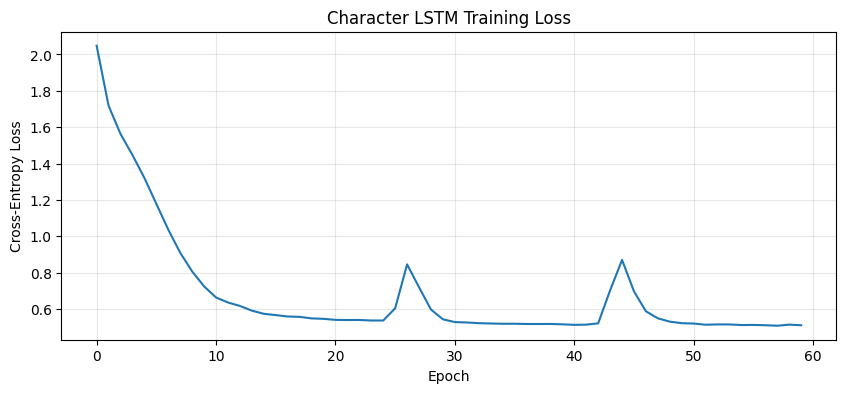

In [18]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Character LSTM Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

## 5.6 Sampling with Different Temperatures

In [19]:
print("Generated dinosaur names at different temperatures:")
print("=" * 50)

for temp in [0.3, 0.6, 0.8, 1.0, 1.5]:
    samples = [sample_name(char_model, char_to_ix, ix_to_char, temperature=temp) for _ in range(8)]
    print(f"\nTemperature={temp}: {', '.join(samples)}")

print("\n" + "=" * 50)
print("Seeded generation (starting with specific letters):")
for seed in ["t", "s", "b", "z"]:
    samples = [sample_name(char_model, char_to_ix, ix_to_char, seed_char=seed) for _ in range(5)]
    print(f"  Seed='{seed}': {', '.join(samples)}")

Generated dinosaur names at different temperatures:

Temperature=0.3: Angaturama, Shanag, Shunosaurus, Aragosaurus, Anchisaurus, Angaturama, Ampelosaurus, Masiakasaurus

Temperature=0.6: Aucasaurus, Pantydraco, Dromiceiomimus, Silvisaurus, Archaeopteryx, Sauropelta, Harpymimus, Hadrosaurus

Temperature=0.8: Barapasaurus, Hypacrosaurus, Nedoceratops, Stegoceras, Kritosaurus, Nqwebasaurus, Maiasaura, Mapusaurus

Temperature=1.0: Edmontosaurus, Pentaceratops, Oryctodromeus, Euoplocephalus, Unenlagia, Pelicanimimus, Huayangosaurus, Pantydraco

Temperature=1.5: Khaan, Achiolophosaurus, Oviraptor, Xiaosaurus, Huayangosaurus, Wannanosaurus, Buitreraptor, Zuniceratops

Seeded generation (starting with specific letters):
  Seed='t': Alarus, Roodon, Herizinosaurus, Herizinosaurus, Rosaurus
  Seed='s': Auropelta, Pinosaurus, Auropelta, Aurornithoides, Auropelta
  Seed='b': Actrosaurus, Uaiasaurus, Roetaurus, Arosaurus, Actrosaurus
  Seed='z': Huanosaurus, Eratosaurus, Osaurus, Erasaurus, Horaptor

---
# Summary

| Feature | Vanilla RNN | GRU | LSTM |
|---------|------------|-----|------|
| Gates | 0 | 2 (reset, update) | 3 (forget, input, output) |
| States | 1 (h) | 1 (h) | 2 (h, c) |
| Gradient highway | No | Yes (via update gate) | Yes (via cell state) |
| Relative params | 1× | ~3× | ~4× |
| Long-range deps | Poor | Good | Good |
| When to use | Short sequences, baselines | Limited data, faster training | Default choice, complex tasks |

**Key insights:**
1. The vanishing gradient problem in Vanilla RNNs is caused by repeated multiplication by $W_{hh}$ during BPTT
2. Both GRU and LSTM solve this by creating **additive** paths for gradient flow (update gate in GRU, cell state in LSTM)
3. **Gradient clipping** (`clip_grad_norm_`) is essential for stable training of any RNN variant
4. In practice, use PyTorch's built-in `nn.LSTM` / `nn.GRU` — they are CuDNN-optimized and much faster than manual loops
5. For most modern NLP tasks, Transformers have replaced RNNs — but understanding RNN mechanics is foundational for grasping attention and memory mechanisms